## R-Star testing with the inclusion of oscillation parameters

The `xsec_` parameters are known as the 'nuisance paramters' since they are there because they have to be there; what is more interesting are the oscillation params which tell us about the PMNS matrix and ulitmately CP violation. We are essentially limit testing R* on data that looks wierd. 

The distribution of delta_m232 is 2 gaussians, one on the rhs of the y axis (referred to as the normal ordering) and one on the left (referred to as reverse ordering); we want to know how R* handles this and compare it R-Hat since the R-Hat diagnostic is based on between chain and within chain variances. This will be an effective comparison between the two diagnostics.

This notebook runs similar code to `basic_sklearn.ipynb` but with the inclusion of oscillation parameters. 

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory
from MaCh3PythonUtils.file_handling.chain_diagnostics import ChainDiagnostics
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import log_loss    


# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import pandas as pd
import seaborn as sns
import gdown

Using mps device

## How does R* behave when 2 identical chain files slowly become more random with the inclusion of oscillation paramters.
> At what value of R* can we say with confidence that the ML Classifier distinguishes between the 2 chains as good as random guessing.

The code below is similar to the code in `basic_sklearn.ipynb` with the addition of the oscillation params.


In [2]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/all_on_ADT2K/identical/")
path_to_1= Path("../models/demo_files 2/all_on_ADT2K/level 1/")
path_to_2= Path("../models/demo_files 2/all_on_ADT2K/level 2/")
path_to_3= Path("../models/demo_files 2/all_on_ADT2K/level 3/")
path_to_4= Path("../models/demo_files 2/all_on_ADT2K/level 4/")
path_to_5= Path("../models/demo_files 2/all_on_ADT2K/level 5/")
path_to_6= Path("../models/demo_files 2/all_on_ADT2K/level 6/")
path_to_7= Path("../models/demo_files 2/all_on_ADT2K/level 7/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]# these will be used later as args in functions (used to calc the dims of the data)
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]




fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(['baseline', 'density', 'Ye',  "xsec_19", "xsec_20"])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        chain_handler.add_additional_plots(['sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000"]) #>0 chooses the normal ordering; <0 chooses reverse ordering; removing the cut chooses both
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

level1_data = temp1[0]
level1_data.ttree_array['ID']= 0

level2_data = temp2[0]
level2_data.ttree_array['ID']= 0

level3_data = temp3[0]
level3_data.ttree_array['ID']= 0

level4_data= temp4[0]
level4_data.ttree_array['ID']=0

level5_data= temp5[0]
level5_data.ttree_array['ID']=0

level6_data= temp6[0]
level6_data.ttree_array['ID']=0

level7_data= temp7[0]
level7_data.ttree_array['ID']=0

# double check if the uniform dist is applied by identifying row (chian id =1) and coloumn (i.e xsec_0)

for id, chain in enumerate(temp_identical[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
identical_data.ttree_array = pd.concat([identical_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp1[1:], start = 1): 
    
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.00000001)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*0.00000001)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*0.00000001)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*0.00000001)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*0.00000001)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*0.00000001)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*0.00000001)
    level1_data.ttree_array = pd.concat([level1_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp2[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.0000001)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*0.0000001)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*0.0000001)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*0.0000001)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*0.0000001)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*0.0000001)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*0.0000001)

    level2_data.ttree_array = pd.concat([level2_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp3[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.000001)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*0.000001)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*0.000001)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*0.000001)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*0.000001)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*0.000001)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*0.000001)
    level3_data.ttree_array = pd.concat([level3_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp4[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.00001)
    
    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*0.00001)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*0.00001)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*0.00001)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*0.00001)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*0.00001)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*0.00001) 
    level4_data.ttree_array = pd.concat([level4_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp5[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.0001)
    
    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*0.0001)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*0.0001)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*0.0001)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*0.0001)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*0.0001)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*0.0001) 
    level5_data.ttree_array = pd.concat([level5_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp6[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}'])))

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12'])))
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23'])))
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13'])))
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12'])))
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23'])))
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))) 
    level6_data.ttree_array = pd.concat([level6_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp7[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(23):
        if m == 19:
            continue
        elif m == 20:
            continue
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*10)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*10)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*10)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*10)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*10)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*10)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*10)  

    level7_data.ttree_array = pd.concat([level7_data.ttree_array, chain.ttree_array])



# First step we need to initialise the factory
path_to_identical.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_id = MLFactory(identical_data, fitting_label, f"{path_to_identical}.pdf")

#hook up paths to MLFactory
path_to_1.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")

path_to_2.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")

path_to_3.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")

path_to_4.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")

path_to_5.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")

path_to_6.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")

path_to_7.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level7 = MLFactory(level7_data, fitting_label, f"{path_to_7}.pdf")


['../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 6/mcmc_Adapt_T2K_all_on_copy

### Training, Testing, Diagnostics: Confusion Matrix, Loss function plots, etc

The code below, will train and test the model on the DataFrame formulated above.

In [ ]:

ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_id.set_training_test_set(0.3)
ml_model_id.train_model()
print(f'results for identical:')
print('=========================')
ml_model_id.test_model_class(identical, 'adapt', 't2k', norm= True, model=ml_model_id)


ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=2, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data
ml_model_1.set_training_test_set(0.3)
ml_model_1.train_model()
print(f'results for level 1:')
print('=========================')
ml_model_1.test_model_class(level1, 'adapt', 't2k', norm= False, model=ml_model_1)


ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_2.set_training_test_set(0.3)
ml_model_2.train_model()
print(f'results for level 2:')
print('=========================')
ml_model_2.test_model_class(level2, 'adapt', 't2k', norm= False, model=ml_model_2)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_3.set_training_test_set(0.3)
ml_model_3.train_model()
print(f'results for level 3:')
print('=========================')
ml_model_3.test_model_class(level3, 'adapt', 't2k', norm= False, model=ml_model_3)


ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=2, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_4.set_training_test_set(0.3)
ml_model_4.train_model()
print(f'results for level 4:')
print('=========================')

ml_model_4.test_model_class(level4, 'adapt', 't2k', norm= False, model=ml_model_4)


ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=2, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_5.set_training_test_set(0.3)
ml_model_5.train_model()
print(f'results for level 5:')
print('=========================')
ml_model_5.test_model_class(level5, 'adapt', 't2k', norm= False, model=ml_model_5)


ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=2, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_6.set_training_test_set(0.3)
ml_model_6.train_model()
print(f'results for level 6:')
print('=========================')
ml_model_6.test_model_class(level6, 'adapt', 't2k', norm= False, model=ml_model_6) 


ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=2, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_7.set_training_test_set(0.3)
ml_model_7.train_model()
print(f'results for level 7:')
print('=========================')
ml_model_7.test_model_class(level7, 'adapt', 't2k', norm= False, model=ml_model_7)




### Calculate multiple R* vals for each level of random noise and append them to a list

In [3]:
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=1, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=1, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data)
ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=1, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=1, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=1, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=1, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
list_id=[]
list1=[]
list2=[]
list3=[]
list4=[]
list5=[]
list6=[]
list7=[]


datapoints= 3
for i in range(datapoints):
    ml_model_id.set_training_test_set(0.3)
    ml_model_id.train_model()
    y=ml_model_id.getRStar_vals(identical, ml_model_id)
    list_id.append(y)

for i in range(datapoints):
    ml_model_1.set_training_test_set(0.3)
    ml_model_1.train_model()
    y=ml_model_1.getRStar_vals(level1, ml_model_1)
    list1.append(y)

for i in range(datapoints):
    ml_model_2.set_training_test_set(0.3)
    ml_model_2.train_model()
    y=ml_model_2.getRStar_vals(level2, ml_model_2)
    list2.append(y)

for i in range(datapoints):
    ml_model_3.set_training_test_set(0.3)
    ml_model_3.train_model()
    y=ml_model_3.getRStar_vals(level3, ml_model_3)
    list3.append(y)

for i in range(datapoints):
    ml_model_4.set_training_test_set(0.3)
    ml_model_4.train_model()
    y=ml_model_4.getRStar_vals(level4, ml_model_4)
    list4.append(y)

for i in range(datapoints):
    ml_model_5.set_training_test_set(0.3)
    ml_model_5.train_model()
    y=ml_model_5.getRStar_vals(level5, ml_model_5)
    list5.append(y)

for i in range(datapoints):
    ml_model_6.set_training_test_set(0.3)
    ml_model_6.train_model()
    y=ml_model_6.getRStar_vals(level6, ml_model_6)
    list6.append(y)
    

for i in range(datapoints):
    ml_model_7.set_training_test_set(0.3)
    ml_model_7.train_model()
    y=ml_model_7.getRStar_vals(identical, ml_model_7)
    list7.append(y)





Training Model
Binning 0.534 GB of training data: 1.289 s
Binning 0.059 GB of validation data: 0.120 s
Fitting gradient boosted rounds:
Fit 10 trees in 10.165 s, (5500 total leaves)
Time spent computing histograms: 3.683s
Time spent finding best splits:  0.804s
Time spent applying splits:      1.365s
Time spent predicting:           0.065s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 0.46885736131169825

R*: 0.9377147226233965

...

Training Model
Binning 0.534 GB of training data: 0.748 s
Binning 0.059 GB of validation data: 0.090 s
Fitting gradient boosted rounds:
Fit 20 trees in 3.682 s, (320 total leaves)
Time spent computing histograms: 0.759s
Time spent finding best splits:  0.048s
Time spent applying splits:      0.301s
Time spent predicting:           0.038s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 1.0

R*: 2.0

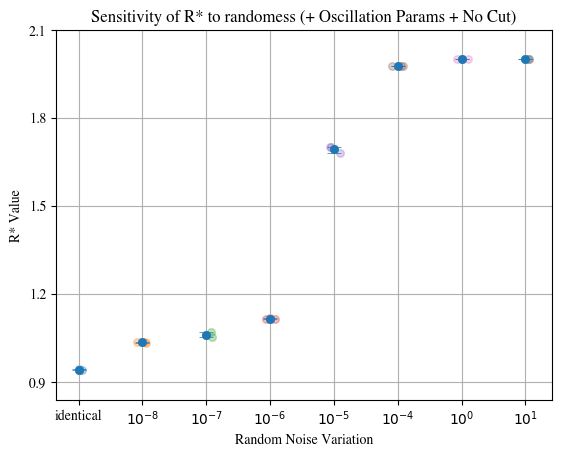

   labels     Mean      Min      Max  Lower Error  Upper Error
identical 0.939667 0.937715 0.942069     0.001952 2.402515e-03
$10^{-8}$ 1.034069 1.032390 1.036135     0.001679 2.065528e-03
$10^{-7}$ 1.058943 1.050889 1.068142     0.008054 9.198879e-03
$10^{-6}$ 1.114090 1.112487 1.116692     0.001603 2.601875e-03
$10^{-5}$ 1.694895 1.681303 1.701815     0.013592 6.919265e-03
$10^{-4}$ 1.976056 1.975864 1.976306     0.000192 2.497664e-04
 $10^{0}$ 1.999999 1.999998 2.000000     0.000001 5.663637e-07
 $10^{1}$ 2.000000 2.000000 2.000000     0.000000 0.000000e+00


In [28]:

lists=[list_id, list1, list2, list3, list4, list5, list6, list7]
concat= list_id + list1 + list2 + list3 + list4 + list5 + list6 +list7

means = np.array([np.mean(vals) for vals in lists])
mins  = np.array([np.min(vals)  for vals in lists])
maxs  = np.array([np.max(vals)  for vals in lists])

lower_err = means - mins
upper_err = maxs  - means
yerr = np.vstack((lower_err, upper_err))


x = np.arange(len(lists)) + 2   

plt.errorbar(x, means,
             yerr=np.absolute(yerr),
             fmt='o',        
             capsize=5,      
             elinewidth=0.5,
             markeredgewidth=0.5)



datapoints = 2
def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))

for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)
labels = ['identical',r'$10^{-8}$', r'$10^{-7}$', r'$10^{-6}$', r'$10^{-5}$', r'$10^{-4}$', r'$10^{0}$', r'$10^{1}$']

plt.rcParams["font.family"] = "Times"


plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], [labels[0], labels[1], labels[2], labels[3], labels[4], labels[5], labels[6], labels[7]])

ymin, ymax = min(concat), max(concat)
pad    = (ymax - ymin) * 0.2
plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list_id)-0.1, max(list7)+0.1)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   

plt.title('Sensitivity of R* to randomess (+ Oscillation Params + No Cut)')
plt.xlabel('Random Noise Variation')
plt.ylabel('R* Value')
plt.grid(True)
plt.savefig('filename.png', dpi=900)

plt.show()



table = pd.DataFrame({
    'labels': labels,
    'Mean': means,
    'Min': mins,
    'Max': maxs,
    'Lower Error': lower_err,
    'Upper Error': upper_err
})

print(table.to_string(index=False))